In [36]:
import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report,confusion_matrix, roc_auc_score,roc_curve)
from imblearn.over_sampling import SMOTE

In [ ]:
data_path ="../data/creditcard.csv"
df = pd.read_csv(data_path)

X = df.drop('Class', axis=1) # feature
y = df['Class']             #target

print(f"X shape: {X.shape}")
print(f"Fraud count: {y.sum()}")
print(f"Normal count: {(y == 0).sum()}")


X shape: (284807, 30)
Fraud count: 492
Normal count: 284315


## Train/Test 

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
#`stratify=y` is very important — we are preserving the fraud rate in the division operation.
#  This means that both the training set and the test set will have 0.17% fraud. 
# If we don't do this, all the fraud could pool together.


print(f"Train set:{X_train.shape}")
print(f"Test set:{X_test.shape}")
print(f"Train fraud:{y_train.sum()}")
print(f"Test fraud:{y_test.sum()}")

Train set:(227845, 30)
Test set:(56962, 30)
Train fraud:394
Test fraud:98


## Scaling

We are only scaling the Amount and Time columns. Columns V1–V28 are already balanced as they have been converted using PCA.

We use StandardScaler to bring features to the same scale. Some features like Amount have much larger values than others, which can mislead models like Logistic Regression. Scaling ensures that all features contribute equally and improves model performance.

In [31]:
scaler_amount = StandardScaler()
scaler_time = StandardScaler()

X_train['Amount'] = scaler_amount.fit_transform(X_train[['Amount']])
X_train['Time'] = scaler_time.fit_transform(X_train[['Time']])

X_test['Amount'] = scaler_amount.transform(X_test[['Amount']])
X_test['Time'] = scaler_time.transform(X_test[['Time']])

print(f"Amount - Avg:{X_train['Amount'].mean():.2f}, std:{X_train['Amount'].std():.2f}")
print(f"Time - Avg:{X_train['Time'].mean():.2f}, std:{X_train['Time'].std():.2f}")

Amount - Avg:0.00, std:1.00
Time - Avg:-0.00, std:1.00


Scaling is fitted only on the training set to prevent data leakage. The same scaler is then applied to the test set using transform().

## SMOTE


We considered different approaches to handle class imbalance: undersampling, class weighting, and SMOTE. Undersampling causes loss of valuable data, while class weighting may not be sufficient due to the very low number of fraud samples.

SMOTE was chosen because it increases the number of fraud samples by generating synthetic data, allowing the model to learn fraud patterns more effectively. This is especially important in fraud detection, where missing a fraud case (false negative) is more critical than a false alarm.

In [32]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote= smote.fit_resample(X_train,y_train)

print(f"Before SMOTE — Normal: {(y_train ==0).sum()}, Fraud: {y_train.sum()}")
print(f"After SMOTE — Normal: {(y_train_smote ==0).sum()}, Fraud: {y_train_smote.sum()}")


Before SMOTE — Normal: 227451, Fraud: 394
After SMOTE — Normal: 227451, Fraud: 227451


# Logistic Regression

In [33]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_smote,y_train_smote)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:,1]


print("===== # Logistic Regression ====")
print(classification_report(y_test,y_pred_lr,target_names=['Normal','Fraud']))
print(f"ROC - AUC: {roc_auc_score(y_test,y_prob_lr):.4f}")

===== # Logistic Regression ====
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC - AUC: 0.9699


SMOTE balanced the training set, but the model learned a bit too aggressively, declaring every suspicious transaction as fraud. This imbalance between Precision and Recall is called a trade-off; increasing one reduces the other. Logistic Regression isn't strong enough for this data.

## XGBoost

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_model.fit(X_train_smote,y_train_smote)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

print("===== ## XGBoost ====")
print(classification_report(y_test,y_pred_xgb,target_names=['Normal','Fraud']))
print(f"ROC - AUC: {roc_auc_score(y_test,y_prob_xgb):.4f}")

===== ## XGBoost ====
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.35      0.87      0.49        98

    accuracy                           1.00     56962
   macro avg       0.67      0.93      0.75     56962
weighted avg       1.00      1.00      1.00     56962

ROC - AUC: 0.9760


The XGBoost model achieves a high recall (0.87), meaning it successfully detects most fraudulent transactions. However, the precision is low (0.35), indicating a high number of false positives. This suggests the model is aggressive in detecting fraud, which is desirable, but requires further tuning to reduce false alarms.

## Random Forest

In [35]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote,y_train_smote)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print("===== ## Random Forest ====")
print(classification_report(y_test,y_pred_rf,target_names=['Normal','Fraud']))
print(f"ROC - AUC: {roc_auc_score(y_test,y_prob_rf):.4f}")

===== ## Random Forest ====
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.43      0.88      0.58        98

    accuracy                           1.00     56962
   macro avg       0.71      0.94      0.79     56962
weighted avg       1.00      1.00      1.00     56962

ROC - AUC: 0.9836


## Model comparison table

              Model  Precision  Recall   F1  ROC-AUC
Logistic Regression       0.06    0.92 0.11   0.9699
            XGBoost       0.35    0.87 0.49   0.9760
      Random Forest       0.43    0.88 0.58   0.9836


C:\Users\MISRA\AppData\Local\Temp\ipykernel_18752\1184136644.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(results_df['Model'], rotation=15, ha='right', fontsize=9)
C:\Users\MISRA\AppData\Local\Temp\ipykernel_18752\1184136644.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(results_df['Model'], rotation=15, ha='right', fontsize=9)
C:\Users\MISRA\AppData\Local\Temp\ipykernel_18752\1184136644.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(results_df['Model'], rotation=15, ha='right', fontsize=9)
C:\Users\MISRA\AppData\Local\Temp\ipykernel_18752\1184136644.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after s

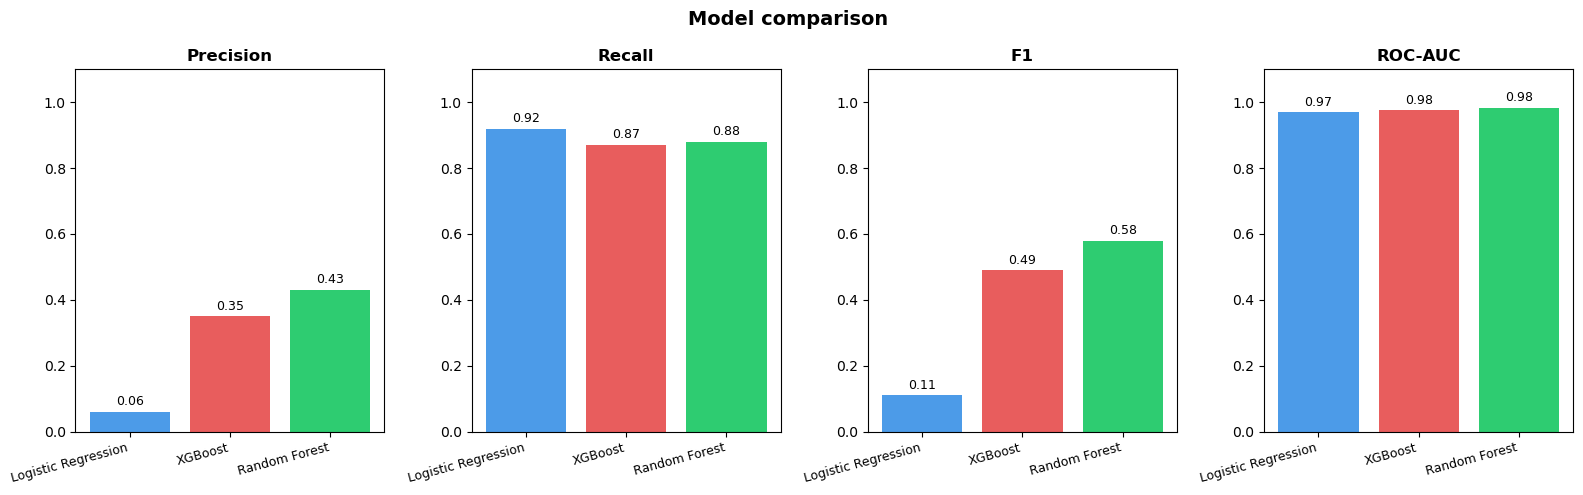

In [38]:
results = {
    'Model': ['Logistic Regression', 'XGBoost', 'Random Forest'],
    'Precision': [0.06, 0.35, 0.43],
    'Recall': [0.92, 0.87, 0.88],
    'F1': [0.11, 0.49, 0.58],
    'ROC-AUC': [0.9699, 0.9760, 0.9836]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
metrics = ['Precision', 'Recall', 'F1', 'ROC-AUC']
colors = ['#4C9BE8', '#E85D5D', '#2ECC71']

for i, metric in enumerate(metrics):
    axes[i].bar(results_df['Model'], results_df[metric], color=colors)
    axes[i].set_title(metric, fontsize=12, fontweight='bold')
    axes[i].set_ylim(0, 1.1)
    axes[i].set_xticklabels(results_df['Model'], rotation=15, ha='right', fontsize=9)
    for j, v in enumerate(results_df[metric]):
        axes[i].text(j, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)

plt.suptitle('Model comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../artifacts/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Precision → Random Forest wins (0.43). It's the most reliable model for the question, "How many of what we call fraud are actually fraud?".

Recall → Logistic Regression wins (0.92), but its Precision is 0.06 — practically unusable. Random Forest and XGBoost are very close (0.88 vs 0.87).

F1 → Random Forest wins by a wide margin (0.58). It's the best model in terms of the balance between Precision and Recall.

ROC-AUC → XGBoost and Random Forest are almost the same (0.98 vs 0.98). Both are very good in terms of overall discrimination power.

Precision performs best in F1 and ROC-AUC. In Recall, it's lower than Logistic Regression, but the Precision of that model is unusable.

## Threshold

F1-score is used because it balances both precision and recall. In fraud detection, focusing only on recall may cause too many false positives, while focusing only on precision may miss fraud cases. F1 helps find the best trade-off between catching fraud and avoiding false alarms.

Best threshold: 0.90
Precision:0.83, Recall:0.74, F1:0.78


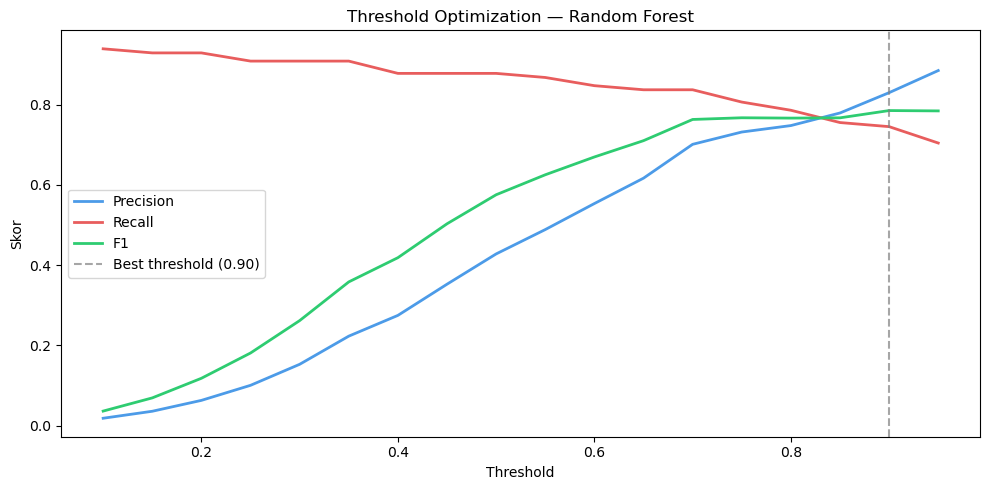

In [46]:
thresholds = np.arange(0.1,1.0,0.05)
precisions, recalls,f1s=[],[],[]

for t in thresholds:
    y_pred_t =(y_prob_rf >= t).astype(int)
    report = classification_report(y_test,y_pred_t,
                                   target_names=['Normal','Fraud'],
                                   output_dict=True,
                                   zero_division=0
                                   )
    precisions.append(report['Fraud']['precision'])
    recalls.append(report['Fraud']['recall'])
    f1s.append(report['Fraud']['f1-score'])


best_idx = np.argmax(f1s)
best_threshold = thresholds[best_idx]
print(f"Best threshold: {best_threshold:.2f}")
print(f"Precision:{precisions[best_idx]:.2f}, Recall:{recalls[best_idx]:.2f}, F1:{f1s[best_idx]:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions, label='Precision', color='#4C9BE8', linewidth=2)
plt.plot(thresholds, recalls, label='Recall', color='#E85D5D', linewidth=2)
plt.plot(thresholds, f1s, label='F1', color='#2ECC71', linewidth=2)
plt.axvline(x=best_threshold, color='gray', linestyle='--', alpha=0.7, label=f'Best threshold ({best_threshold:.2f})')
plt.xlabel('Threshold')
plt.ylabel('Skor')
plt.title('Threshold Optimization — Random Forest')
plt.legend()
plt.tight_layout()
plt.savefig('../artifacts/threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

After threshold tuning, the model achieved a precision of 0.83 and recall of 0.74. This indicates a strong balance between detecting fraudulent transactions and reducing false positives. The model becomes more selective, improving reliability while slightly sacrificing recall.

## Save the model

In [47]:
THRESHOLD = 0.90

joblib.dump(rf_model, '../artifacts/model.pkl')
joblib.dump(scaler_amount, '../artifacts/scaler_amount.pkl')
joblib.dump(scaler_time, '../artifacts/scaler_time.pkl')

threshold_config = {'threshold': THRESHOLD}
joblib.dump(threshold_config, '../artifacts/threshold.pkl')


['../artifacts/threshold.pkl']